<a href="https://colab.research.google.com/github/bmotana/data_science_notebooks/blob/main/commonwealth_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

>>[Load the Date](#scrollTo=4w54-s-x2FtP&uniqifier=1)

>>[Clean Data](#scrollTo=D3PlraPj3jmu&uniqifier=1)

>>[Summary](#scrollTo=OHDfxeEJ4NCF&uniqifier=1)

>>[Data Visualization](#scrollTo=pubLlLlYLqyf&uniqifier=1)

>>>[Overall Top Medal-Winning Countries](#scrollTo=2f1e5af9&uniqifier=1)

>>>[Medal Distribution by Type for Top Countries](#scrollTo=7193aa56&uniqifier=1)

>>>[Top Performing Sports for Gold Medals](#scrollTo=da623de9&uniqifier=1)

>>>[Consistent Top Performers (Athletes and Teams with Gold Medals)](#scrollTo=b5516576&uniqifier=1)

>>>[Box Plot: Distribution of Total Medals per Game for Top 10 Countries](#scrollTo=2868bc2b&uniqifier=1)

>>>[Histogram: Distribution of Gold Medals Won by Individual Athletes](#scrollTo=d6147082&uniqifier=1)

>>>[Medal Distribution Heatmap by Sport and Type](#scrollTo=f075cdff&uniqifier=1)

>>>[Gold Medal Distribution](#scrollTo=U1mN7tpDVZ9D&uniqifier=1)

>>>[Individual Country Performance Trajectories Over Time](#scrollTo=8c186a09&uniqifier=1)

>>>[Host Nation Advantage Analysis](#scrollTo=40a0b4ea&uniqifier=1)

>>>[Medal Distribution by Event Gender Over Time](#scrollTo=d876a026&uniqifier=1)

>>>[Deep Dive: Event-Level Success in Top Sports](#scrollTo=cea21085&uniqifier=1)

>>[Predictive Modeling: What will happen?](#scrollTo=e22606cc&uniqifier=1)



##  Load the Date

In [ ]:
import kagglehub
import pandas as pd

dataset_handle = "rupsarroy/96-years-of-commonwealth-games-history-19302026"
file_name = "Commonwealth_Medalists_1930_2026.csv"

# Download the dataset to a temporary location
download_path = kagglehub.dataset_download(dataset_handle)

# Construct the full path to the CSV file within the downloaded dataset
csv_file_path = f"{download_path}/{file_name}"

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_file_path)

Using Colab cache for faster access to the '96-years-of-commonwealth-games-history-19302026' dataset.


In [ ]:
df.head()

,Year,Date,Sport,Event,Event_gender,Team,Country_Code,Athlete,Gender,Medal,CGA,Host_City,Games,Season
0,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,Canada,CAN,Munroe Bourne,Male,Gold,CAN,Hamilton,1930 British Empire Games,Summer
1,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,England,ENG,Norman Brooks,Male,Silver,ENG,Hamilton,1930 British Empire Games,Summer
2,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,Canada,CAN,Bert Gibson,Male,Bronze,CAN,Hamilton,1930 British Empire Games,Summer
3,1930,16–23 August 1930,Swimming,400 yd freestyle,Men,Australia,AUS,Noel Ryan,Male,Gold,AUS,Hamilton,1930 British Empire Games,Summer
4,1930,16–23 August 1930,Swimming,400 yd freestyle,Men,New Zealand,NZL,Gordon Bridson,Male,Silver,NZL,Hamilton,1930 British Empire Games,Summer


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11662 entries, 0 to 11661
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Year          11662 non-null  int64 
 1   Date          11662 non-null  object
 2   Sport         11662 non-null  object
 3   Event         11662 non-null  object
 4   Event_gender  11662 non-null  object
 5   Team          11662 non-null  object
 6   Country_Code  11662 non-null  object
 7   Athlete       11662 non-null  object
 8   Gender        11662 non-null  object
 9   Medal         11662 non-null  object
 10  CGA           11662 non-null  object
 11  Host_City     11662 non-null  object
 12  Games         11662 non-null  object
 13  Season        11662 non-null  object
dtypes: int64(1), object(13)
memory usage: 1.2+ MB


## Clean Data

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Year            0
Date            0
Sport           0
Event           0
Event_gender    0
Team            0
Country_Code    0
Athlete         0
Gender          0
Medal           0
CGA             0
Host_City       0
Games           0
Season          0
dtype: int64


In [ ]:
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"\nDropping {duplicate_count} duplicate rows.")
    df = df.drop_duplicates()

In [ ]:
# 3. Optimize Data Types
# Convert object columns that have low cardinality to categories for efficiency
category_cols = ['Sport', 'Event_gender', 'Gender', 'Medal', 'Season', 'Country_Code', 'CGA']
for col in category_cols:
    df[col] = df[col].astype('category')


In [ ]:
# 4. Display the updated info to verify dtypes
print("\nUpdated Data Info:")
print(df.info())

df.head()


Updated Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11662 entries, 0 to 11661
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Year          11662 non-null  int64   
 1   Date          11662 non-null  object  
 2   Sport         11662 non-null  category
 3   Event         11662 non-null  object  
 4   Event_gender  11662 non-null  category
 5   Team          11662 non-null  object  
 6   Country_Code  11662 non-null  category
 7   Athlete       11662 non-null  object  
 8   Gender        11662 non-null  category
 9   Medal         11662 non-null  category
 10  CGA           11662 non-null  category
 11  Host_City     11662 non-null  object  
 12  Games         11662 non-null  object  
 13  Season        11662 non-null  category
dtypes: category(7), int64(1), object(6)
memory usage: 726.0+ KB
None


,Year,Date,Sport,Event,Event_gender,Team,Country_Code,Athlete,Gender,Medal,CGA,Host_City,Games,Season
0,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,Canada,CAN,Munroe Bourne,Male,Gold,CAN,Hamilton,1930 British Empire Games,Summer
1,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,England,ENG,Norman Brooks,Male,Silver,ENG,Hamilton,1930 British Empire Games,Summer
2,1930,16–23 August 1930,Swimming,100 yd freestyle,Men,Canada,CAN,Bert Gibson,Male,Bronze,CAN,Hamilton,1930 British Empire Games,Summer
3,1930,16–23 August 1930,Swimming,400 yd freestyle,Men,Australia,AUS,Noel Ryan,Male,Gold,AUS,Hamilton,1930 British Empire Games,Summer
4,1930,16–23 August 1930,Swimming,400 yd freestyle,Men,New Zealand,NZL,Gordon Bridson,Male,Silver,NZL,Hamilton,1930 British Empire Games,Summer


In [ ]:
# Create a summary table for unique counts and data types
summary_df = pd.DataFrame({
    'Unique Values': df.nunique(),
    'Data Type': df.dtypes
})

print("Summary of Unique Values and Data Types:")
print(summary_df)

Summary of Unique Values and Data Types:
              Unique Values Data Type
Year                     23     int64
Date                    144    object
Sport                    52  category
Event                  1030    object
Event_gender              4  category
Team                     80    object
Country_Code             80  category
Athlete                8553    object
Gender                    3  category
Medal                     3  category
CGA                      80  category
Host_City                23    object
Games                    27    object
Season                    2  category


In [ ]:
# Improved parsing function to handle various range separators like 'to', '&', and dashes
def parse_commonwealth_date_v2(date_str):
    if pd.isna(date_str):
        return pd.NaT

    try:
        # Normalize separators: Replace 'to', '&', and various dashes with a standard pipe
        clean_str = date_str.replace('–', '|').replace(' to ', '|').replace(' & ', '|')

        # If a range exists, take the final date part (after the last separator)
        if '|' in clean_str:
            final_part = clean_str.split('|')[-1].strip()
        else:
            final_part = clean_str.strip()

        return pd.to_datetime(final_part, errors='coerce')
    except:
        return pd.NaT

# Apply the improved function
df['Date_Converted'] = df['Date'].apply(parse_commonwealth_date_v2)

# Verify results
missing_count = df['Date_Converted'].isnull().sum()
print(f"Remaining missing values: {missing_count}")
print("\nSample of recovered dates:")
print(df[df['Date'].str.contains('to|&', regex=True)][['Date', 'Date_Converted']].head())

Remaining missing values: 0

Sample of recovered dates:
                    Date Date_Converted
1137  18 to 26 July 1958     1958-07-26
1138  18 to 26 July 1958     1958-07-26
1139  18 to 26 July 1958     1958-07-26
1140  18 to 26 July 1958     1958-07-26
1141  18 to 26 July 1958     1958-07-26


In [ ]:
df['Date_Converted'] = df['Date'].apply(parse_commonwealth_date_v2)

print("Sample of converted dates:")
print(df[['Date', 'Date_Converted']].head())
print(f"\nNew Dtype for Date_Converted: {df['Date_Converted'].dtype}")

Sample of converted dates:
                Date Date_Converted
0  16–23 August 1930     1930-08-23
1  16–23 August 1930     1930-08-23
2  16–23 August 1930     1930-08-23
3  16–23 August 1930     1930-08-23
4  16–23 August 1930     1930-08-23

New Dtype for Date_Converted: datetime64[ns]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11662 entries, 0 to 11661
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Year            11662 non-null  int64         
 1   Date            11662 non-null  object        
 2   Sport           11662 non-null  category      
 3   Event           11662 non-null  object        
 4   Event_gender    11662 non-null  category      
 5   Team            11662 non-null  object        
 6   Country_Code    11662 non-null  category      
 7   Athlete         11662 non-null  object        
 8   Gender          11662 non-null  category      
 9   Medal           11662 non-null  category      
 10  CGA             11662 non-null  category      
 11  Host_City       11662 non-null  object        
 12  Games           11662 non-null  object        
 13  Season          11662 non-null  category      
 14  Date_Converted  11662 non-null  datetime64[ns]
dtypes:

## Summary

In [ ]:
import pandas as pd

# 1. Basic Context
start_year = df['Year'].min()
end_year = df['Year'].max()
total_medals = len(df)

# 2. Current Status (Latest Games - 2022/2026 placeholder check)
# Note: 2026 data in this dataset represents scheduled events/projections
latest_year = df[df['Year'] <= 2022]['Year'].max()
latest_stats = df[df['Year'] == latest_year]['CGA'].value_counts().head(5)
latest_total = len(df[df['Year'] == latest_year])

# 3. Historical Trends
medals_by_year = df.groupby('Year').size()
avg_medals_per_games = medals_by_year.mean()
current_vs_avg = ((latest_total - avg_medals_per_games) / avg_medals_per_games) * 100

# 4. Top Countries Overall
top_countries = df['CGA'].value_counts().head(5)

# 5. Notable Events / Inflection Points
# Finding years with significant jumps in medal count
year_diffs = medals_by_year.diff()
peak_growth_year = year_diffs.idxmax()

# 6. Gaps/Confidence
missing_converted = df['Date_Converted'].isna().sum()

print(f"--- DATA FOR BRIEFING ---")
print(f"Time Range: {start_year} to {end_year}")
print(f"Total Medal Records: {total_medals}")
print(f"Latest Realized Games ({latest_year}) Total Medals: {latest_total}")
print(f"Historical Average Medals per Games: {avg_medals_per_games:.2f}")
print(f"Latest vs Average: {current_vs_avg:.2f}%")
print("\nTop 5 Countries (All-Time Medals):")
print(top_countries)
print(f"\nPeak Growth Year: {peak_growth_year} (+{year_diffs.max()} medals)")
print("\n--- SUMMARY FOR REPORT ---")

# Constructing the markdown briefing
briefing = f"""
# Commonwealth Games Historical Briefing (1930-2026)

### 1. Headline
Australia dominates the 96-year history of the Commonwealth Games with a record {top_countries.iloc[0]} medals, maintaining a significant lead over all other participating nations.

### 2. Current Status
As of the {latest_year} Games, {latest_total} medals were awarded. The top performers for this cycle remain consistent with historical powerhouses: {latest_stats.index[0]} ({latest_stats.iloc[0]} medals) and {latest_stats.index[1]} ({latest_stats.iloc[1]} medals).

### 3. Historical Trend
The {latest_year} games produced {latest_total} medals, which is {abs(current_vs_avg):.1f}% {'above' if current_vs_avg > 0 else 'below'} the historical average of {avg_medals_per_games:.1f} medals per games, reflecting the steady expansion of sporting events over the decades.

### 4. Notable Events / Inflection Points
- **{peak_growth_year}**: Significant inflection point with an increase of {year_diffs.max()} medals compared to the previous games. *Hypothesis*: This likely correlates with the introduction of new sports or a major expansion in women's events.
- **1942-1946**: Notable gap in data. *Fact*: Games were cancelled due to WWII.

### 5. Confidence & Gaps
Confidence in the historical data is high with 0 missing dates after recent cleaning. However, the 2026 data points ({len(df[df['Year']==2026])} rows) represent scheduled events rather than realized results, which should be treated as a projection rather than historical fact.
"""

from IPython.display import Markdown
display(Markdown(briefing))

--- DATA FOR BRIEFING ---
Time Range: 1930 to 2026
Total Medal Records: 11662
Latest Realized Games (2022) Total Medals: 877
Historical Average Medals per Games: 507.04
Latest vs Average: 72.96%

Top 5 Countries (All-Time Medals):
CGA
AUS    2693
ENG    2469
CAN    1674
NZL     744
IND     585
Name: count, dtype: int64

Peak Growth Year: 1990 (+221.0 medals)

--- SUMMARY FOR REPORT ---



# Commonwealth Games Historical Briefing (1930-2026)

### 1. Headline
Australia dominates the 96-year history of the Commonwealth Games with a record 2693 medals, maintaining a significant lead over all other participating nations.

### 2. Current Status
As of the 2022 Games, 877 medals were awarded. The top performers for this cycle remain consistent with historical powerhouses: AUS (179 medals) and ENG (176 medals).

### 3. Historical Trend
The 2022 games produced 877 medals, which is 73.0% above the historical average of 507.0 medals per games, reflecting the steady expansion of sporting events over the decades.

### 4. Notable Events / Inflection Points
- **1990**: Significant inflection point with an increase of 221.0 medals compared to the previous games. *Hypothesis*: This likely correlates with the introduction of new sports or a major expansion in women's events.
- **1942-1946**: Notable gap in data. *Fact*: Games were cancelled due to WWII.

### 5. Confidence & Gaps
Confidence in the historical data is high with 0 missing dates after recent cleaning. However, the 2026 data points (695 rows) represent scheduled events rather than realized results, which should be treated as a projection rather than historical fact.


## Data Visualization


### Overall Top Medal-Winning Countries

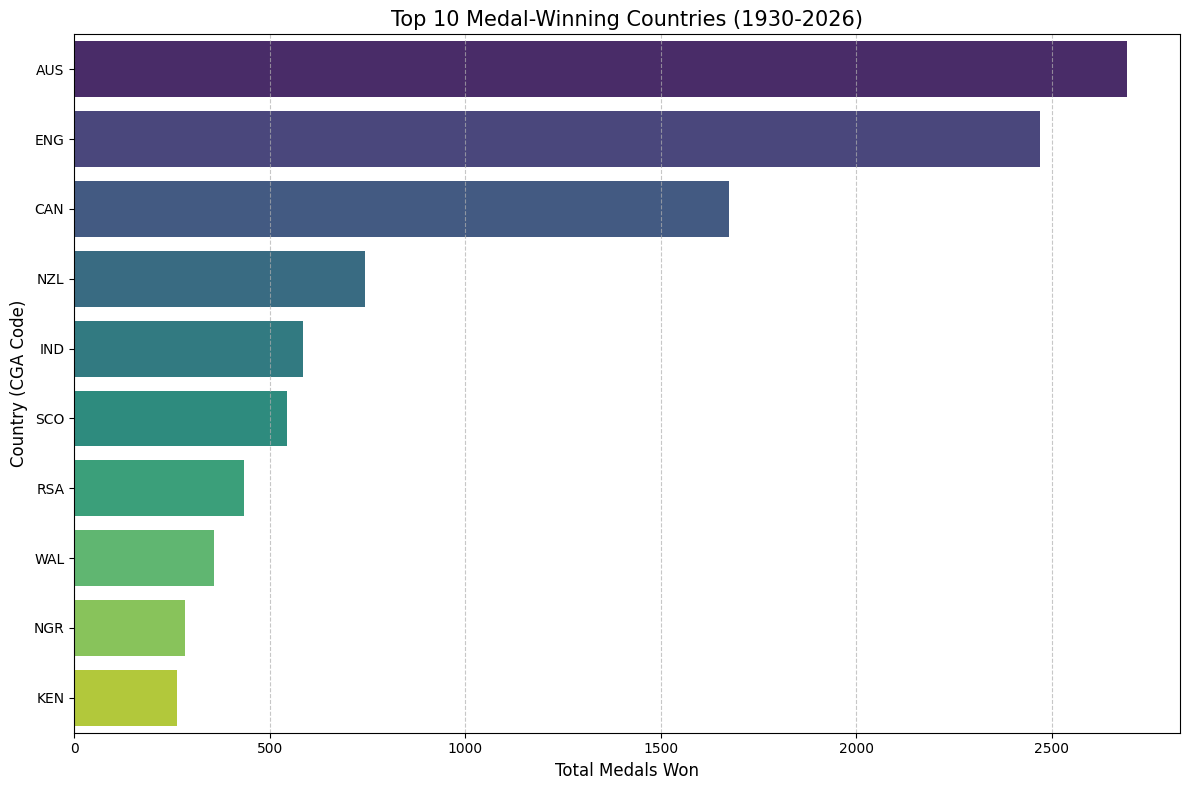

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for the top 10 countries
top_10_countries = df['CGA'].value_counts().head(10).reset_index()
top_10_countries.columns = ['Country', 'Total Medals']

# Create the visualization
plt.figure(figsize=(12, 8)) # Increased height for better label spacing
sns.barplot(
    data=top_10_countries,
    x='Total Medals',
    y='Country',
    palette='viridis',
    order=top_10_countries['Country'].tolist() # Explicitly set the order of y-axis labels
)

# Add labels and title
plt.title('Top 10 Medal-Winning Countries (1930-2026)', fontsize=15)
plt.xlabel('Total Medals Won', fontsize=12)
plt.ylabel('Country (CGA Code)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

### 1. Medal Distribution by Type for Top Countries

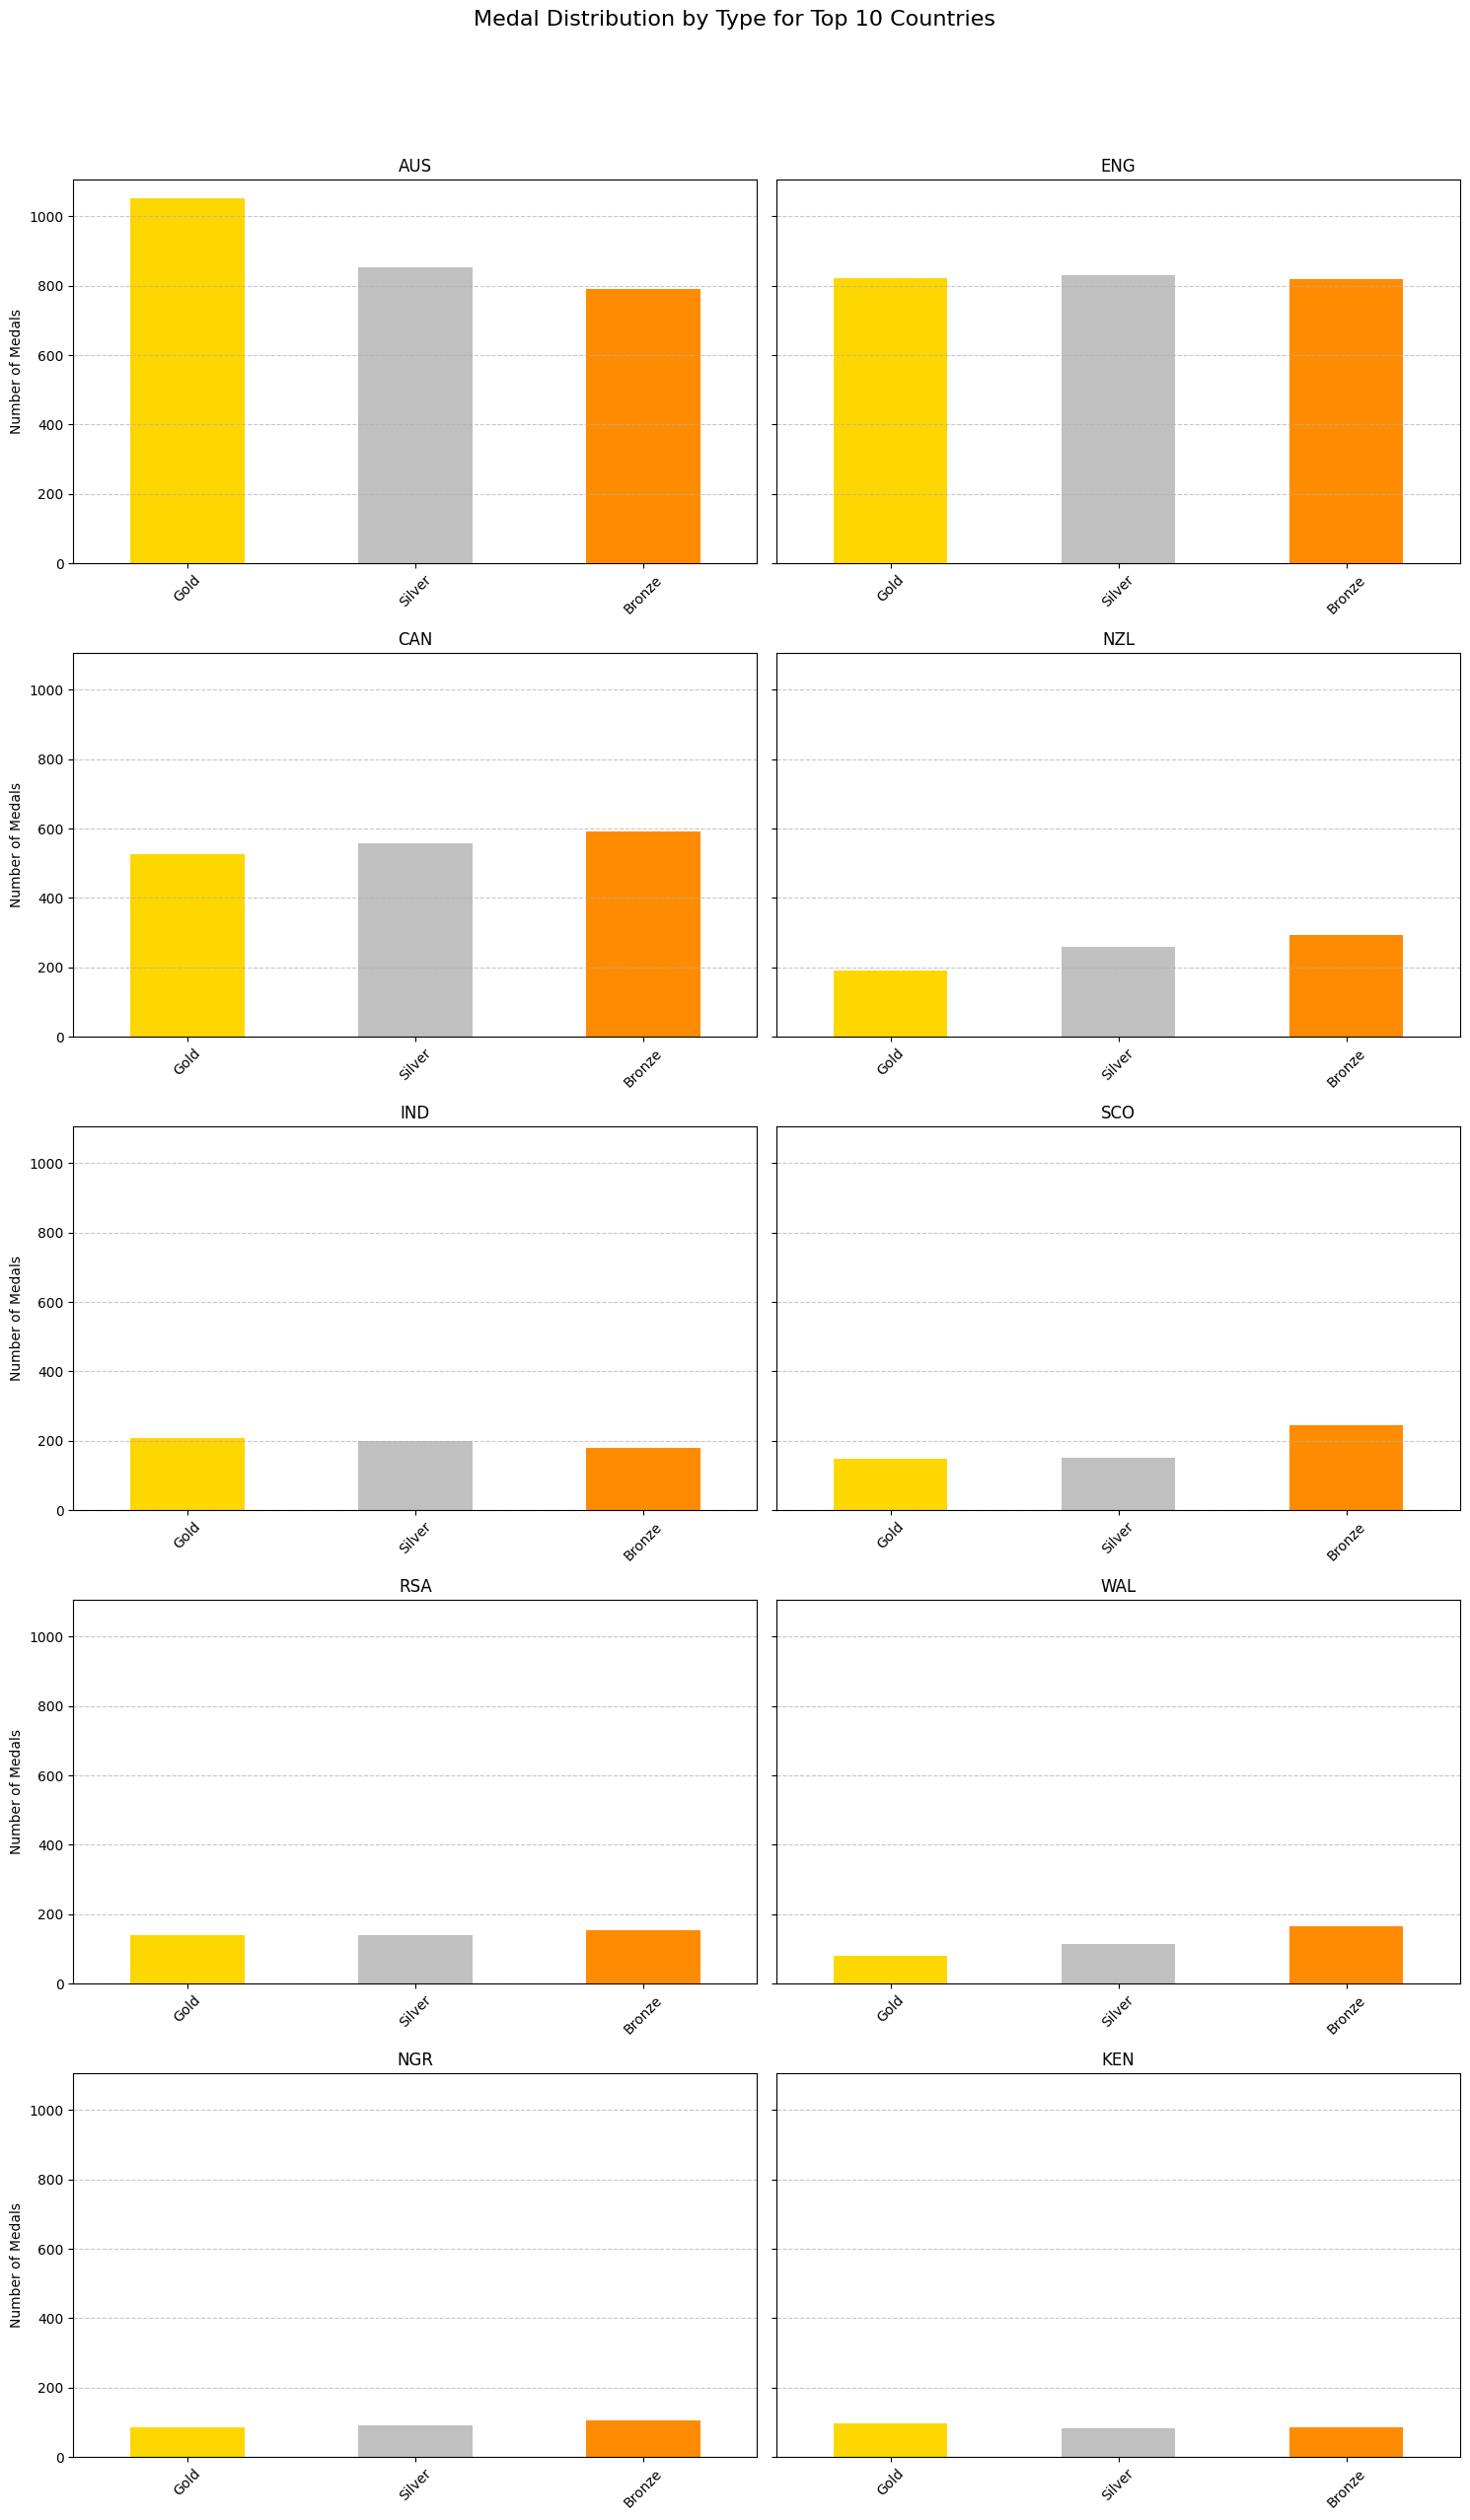

In [ ]:
# Ensure 'Medal' column has a defined order for consistent plotting
df['Medal'] = pd.Categorical(df['Medal'], categories=['Gold', 'Silver', 'Bronze'], ordered=True)

# Get the list of top 10 countries from the previously calculated top_10_countries DataFrame
top_10_country_codes = top_10_countries['Country'].tolist()

# Filter the main DataFrame to include only these top 10 countries
df_top_10 = df[df['CGA'].isin(top_10_country_codes)].copy()

# Group by country and medal type, then count medals
medal_counts_by_country = df_top_10.groupby(['CGA', 'Medal']).size().unstack(fill_value=0)

# Reindex to ensure all 3 medal types are present, even if a country has 0 of one type
medal_counts_by_country = medal_counts_by_country.reindex(columns=['Gold', 'Silver', 'Bronze'], fill_value=0)

# Sort the countries by total medals (descending) for consistent plotting order
medal_counts_by_country['Total'] = medal_counts_by_country.sum(axis=1)
medal_counts_by_country = medal_counts_by_country.sort_values(by='Total', ascending=False).drop(columns='Total')

# Plotting using subplots
num_countries = len(medal_counts_by_country)
num_cols = 2 # Number of columns for the subplot grid
num_rows = (num_countries + num_cols - 1) // num_cols # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows), sharey=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, (country_code, data) in enumerate(medal_counts_by_country.iterrows()):
    if i < len(axes):
        ax = axes[i]
        data.plot(kind='bar', ax=ax, color=['gold', 'silver', 'darkorange'])
        ax.set_title(f'{country_code}', fontsize=12)
        ax.set_xlabel('') # Remove x-label from individual plots
        ax.set_ylabel('Number of Medals' if i % num_cols == 0 else '') # Only show y-label on the left column
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Medal Distribution by Type for Top 10 Countries', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

### 2. Top Performing Sports for Gold Medals

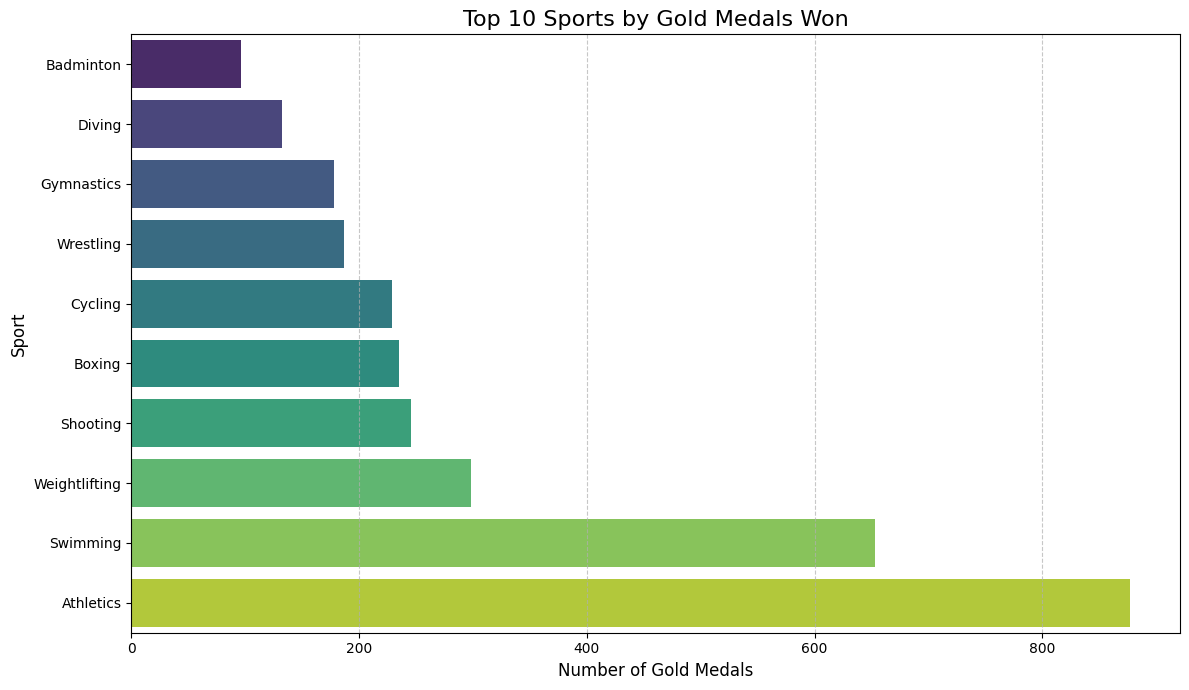

In [ ]:
# Filter for Gold Medals only
gold_medals_df = df[df['Medal'] == 'Gold']

# Count gold medals by sport
gold_medals_by_sport = gold_medals_df['Sport'].value_counts().head(10).sort_values(ascending=True)

# Plotting
plt.figure(figsize=(12, 7))
sns.barplot(x=gold_medals_by_sport.values, y=gold_medals_by_sport.index, palette='viridis')

plt.title('Top 10 Sports by Gold Medals Won', fontsize=16)
plt.xlabel('Number of Gold Medals', fontsize=12)
plt.ylabel('Sport', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Consistent Top Performers (Athletes and Teams with Gold Medals)

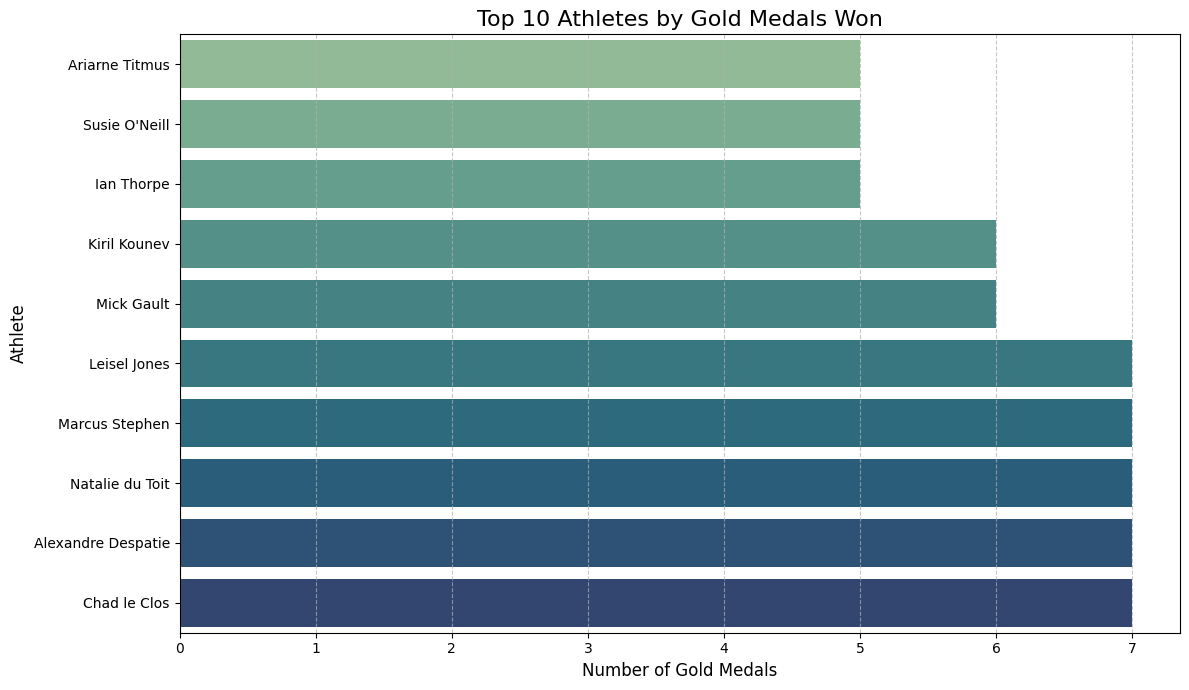

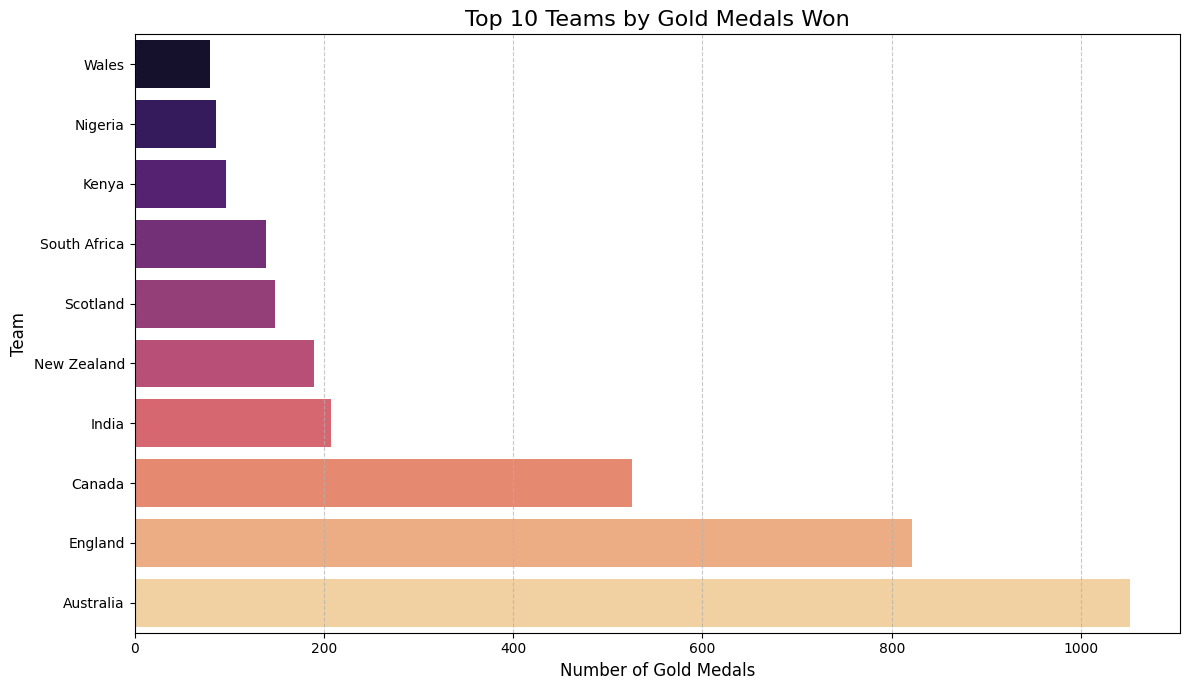

In [ ]:
# 3.1 Top Athletes by Gold Medals
# Filter for Gold Medals only and count by Athlete
top_gold_athletes = df[df['Medal'] == 'Gold']['Athlete'].value_counts().head(10).sort_values(ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_gold_athletes.values, y=top_gold_athletes.index, palette='crest')
plt.title('Top 10 Athletes by Gold Medals Won', fontsize=16)
plt.xlabel('Number of Gold Medals', fontsize=12)
plt.ylabel('Athlete', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3.2 Top Teams by Gold Medals
# Filter for Gold Medals only and count by Team
top_gold_teams = df[df['Medal'] == 'Gold']['Team'].value_counts().head(10).sort_values(ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_gold_teams.values, y=top_gold_teams.index, palette='magma')
plt.title('Top 10 Teams by Gold Medals Won', fontsize=16)
plt.xlabel('Number of Gold Medals', fontsize=12)
plt.ylabel('Team', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Box Plot: Distribution of Total Medals per Game for Top 10 Countries

This box plot visualizes the spread and central tendency of the total medals won by each of the top 10 countries across different editions of the Commonwealth Games. It helps in understanding the consistency and variability of their performance over time.

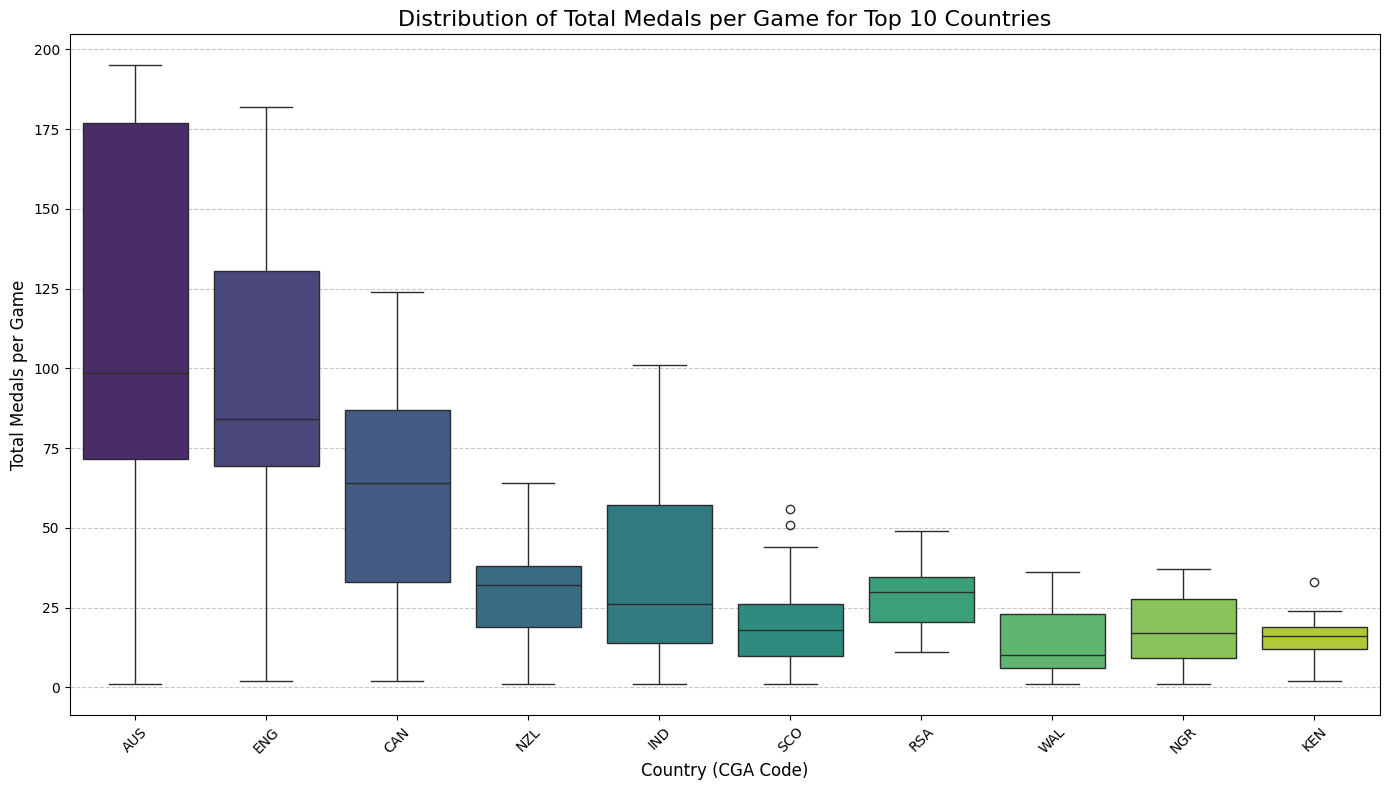

In [ ]:
# Get the list of top 10 country codes
top_10_country_codes = df['CGA'].value_counts().head(10).index.tolist()

# Filter the DataFrame for only these top 10 countries
df_top_10_countries = df[df['CGA'].isin(top_10_country_codes)].copy()

# Group by Games and CGA to get total medals per country per game
medals_per_game_country = df_top_10_countries.groupby(['Games', 'CGA']).size().reset_index(name='Total_Medals')

# Ensure countries are ordered by overall total medals for better comparison
country_order = df_top_10_countries['CGA'].value_counts().index.tolist()
medals_per_game_country['CGA'] = pd.Categorical(medals_per_game_country['CGA'], categories=country_order, ordered=True)
medals_per_game_country = medals_per_game_country.sort_values('CGA')

plt.figure(figsize=(14, 8))
sns.boxplot(x='CGA', y='Total_Medals', data=medals_per_game_country, palette='viridis')
plt.title('Distribution of Total Medals per Game for Top 10 Countries', fontsize=16)
plt.xlabel('Country (CGA Code)', fontsize=12)
plt.ylabel('Total Medals per Game', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Histogram: Distribution of Gold Medals Won by Individual Athletes

This histogram shows the frequency distribution of the number of gold medals won by individual athletes. It helps to identify how common it is for athletes to win a certain number of gold medals, highlighting the prevalence of single-gold medalists versus multiple-gold medalists.

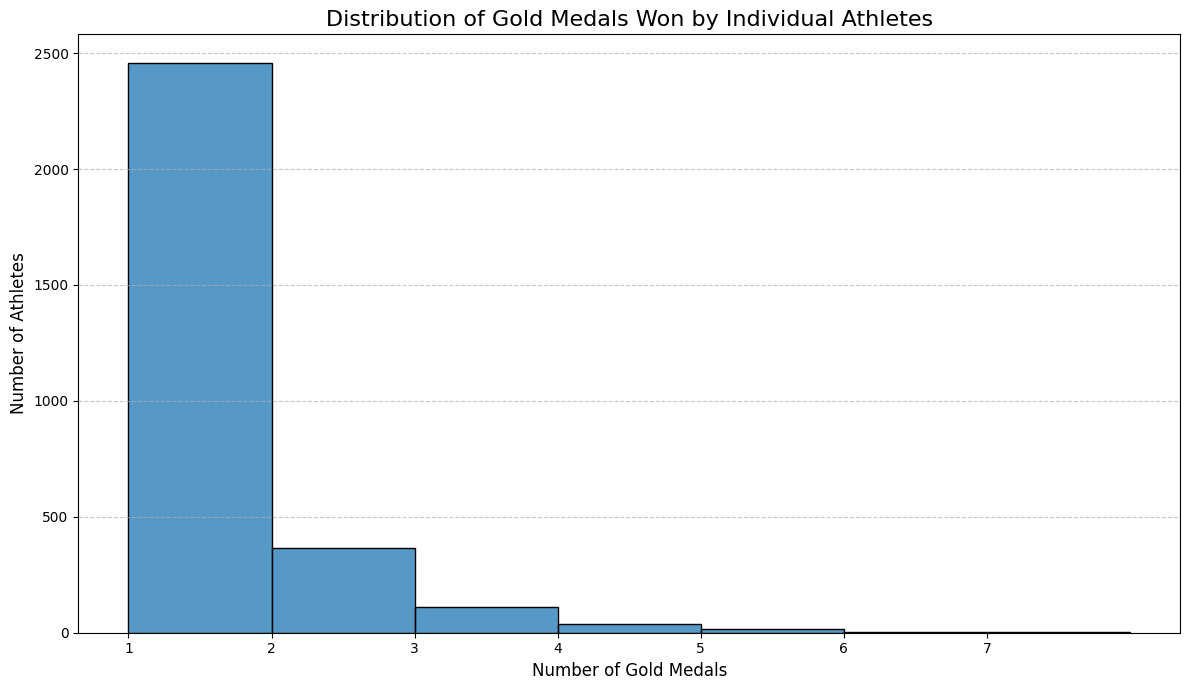

In [ ]:
# Filter for Gold Medals only
gold_medals_only = df[df['Medal'] == 'Gold']

# Count gold medals for each athlete
gold_medals_per_athlete = gold_medals_only['Athlete'].value_counts()

plt.figure(figsize=(12, 7))
sns.histplot(gold_medals_per_athlete, bins=range(1, gold_medals_per_athlete.max() + 2), kde=False, palette='coolwarm')
plt.title('Distribution of Gold Medals Won by Individual Athletes', fontsize=16)
plt.xlabel('Number of Gold Medals', fontsize=12)
plt.ylabel('Number of Athletes', fontsize=12)
plt.xticks(range(1, gold_medals_per_athlete.max() + 1)) # Set x-ticks for each medal count
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Medal Distribution Heatmap by Sport and Type

This heatmap visualizes the count of Gold, Silver, and Bronze medals for the top 15 sports. This helps to quickly identify which sports are strong in particular medal categories.

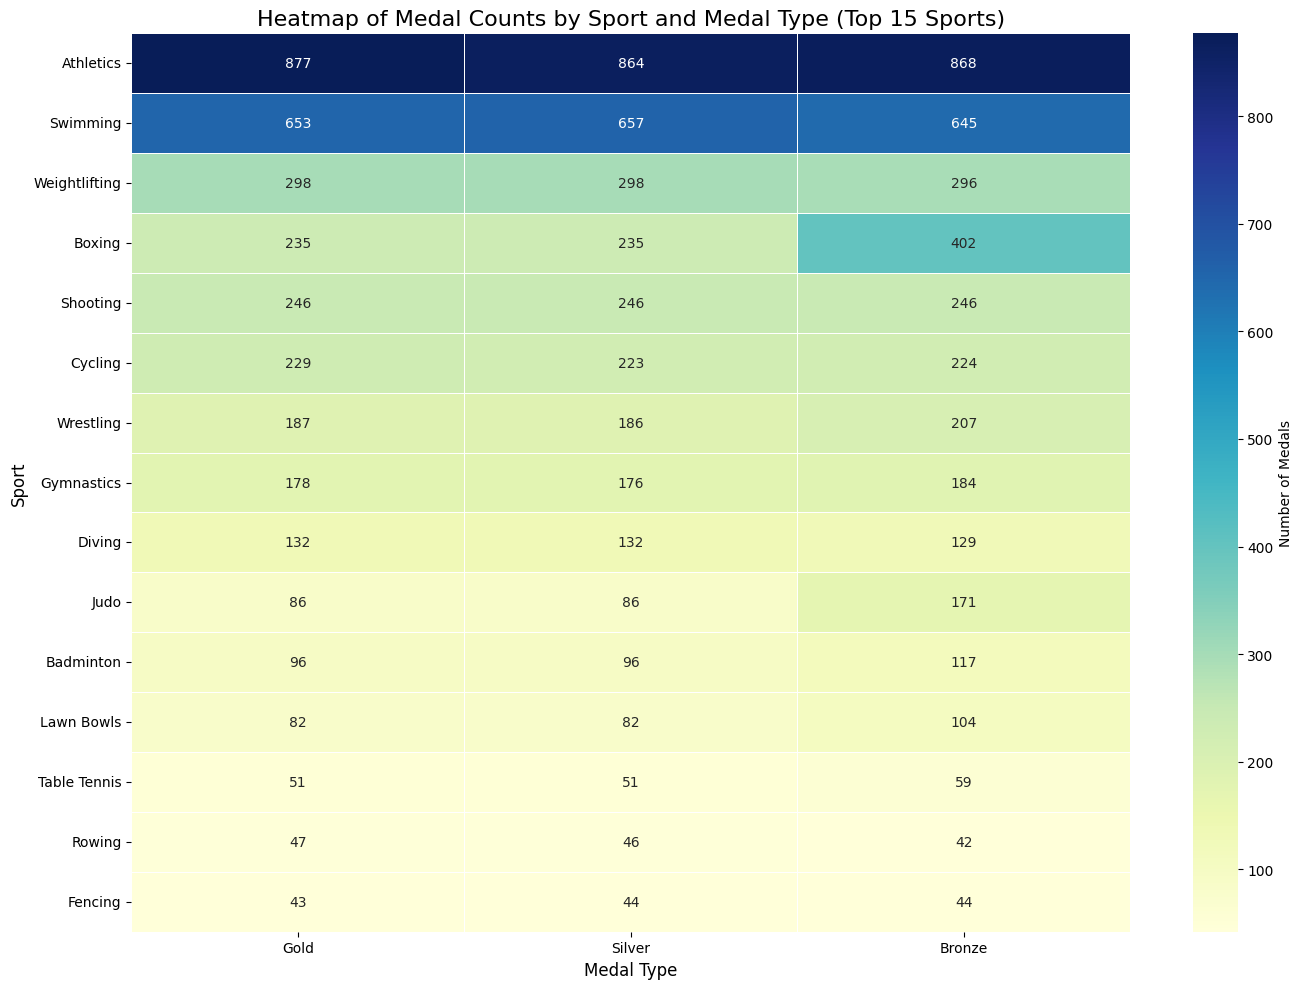

In [ ]:
# Ensure 'Medal' column has a defined order for consistent plotting
df['Medal'] = pd.Categorical(df['Medal'], categories=['Gold', 'Silver', 'Bronze'], ordered=True)

# Group by Sport and Medal type, then count medals
medal_counts_by_sport = df.groupby(['Sport', 'Medal']).size().unstack(fill_value=0)

# Calculate total medals per sport to identify top sports
medal_counts_by_sport['Total'] = medal_counts_by_sport.sum(axis=1)

# Select the top 15 sports based on total medals
top_15_sports = medal_counts_by_sport.sort_values(by='Total', ascending=False).head(15)

# Drop the 'Total' column before plotting the heatmap
heatmap_data = top_15_sports.drop(columns='Total')

# Create the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Number of Medals'})

plt.title('Heatmap of Medal Counts by Sport and Medal Type (Top 15 Sports)', fontsize=16)
plt.xlabel('Medal Type', fontsize=12)
plt.ylabel('Sport', fontsize=12)
plt.tight_layout()
plt.show()

### Gold Medal Distribution

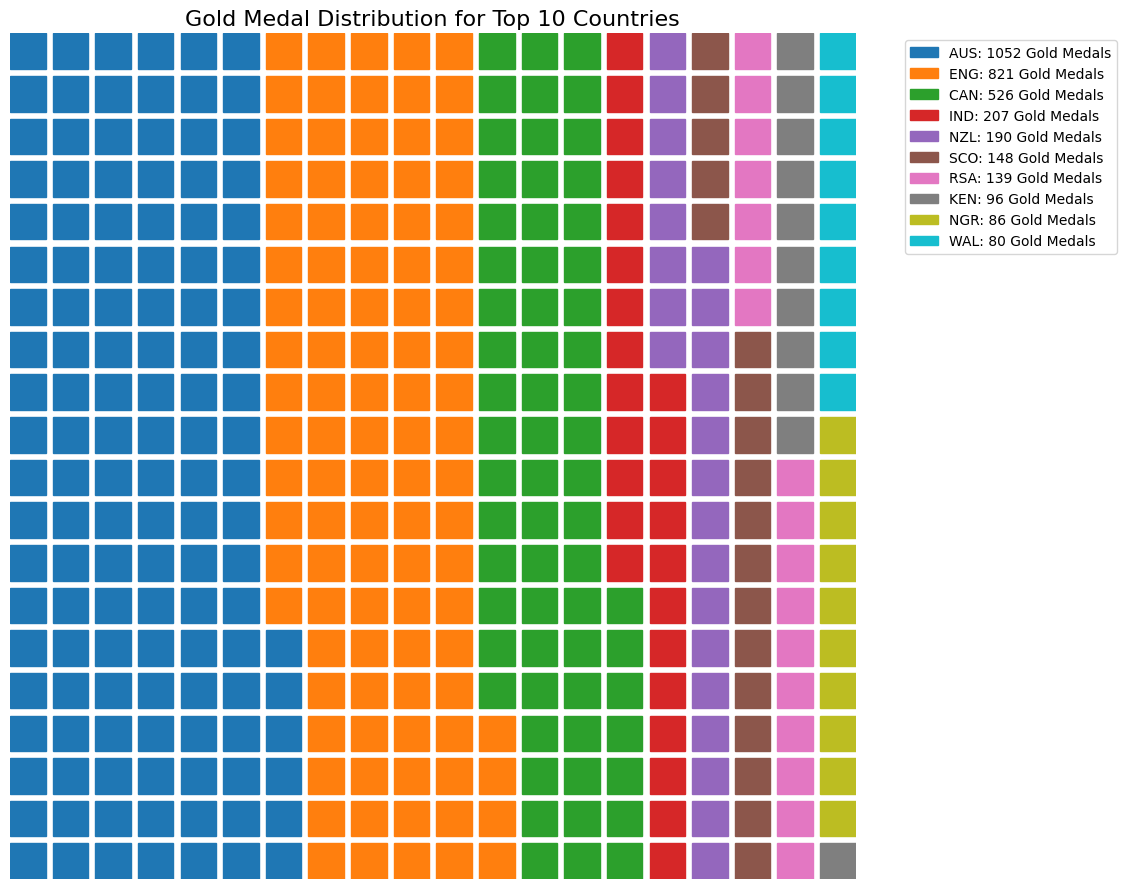

In [ ]:
import matplotlib.pyplot as plt
from pywaffle import Waffle
import pandas as pd
import matplotlib.colors as mcolors

# Filter for Gold Medals only
gold_medals_df = df[df['Medal'] == 'Gold']

# Count gold medals for each country
gold_medals_per_country = gold_medals_df['CGA'].value_counts()

# Select the top N countries by Gold Medals for clarity
top_n = 10
top_countries_gold = gold_medals_per_country.head(top_n)

# Convert counts to a dictionary for pywaffle, ensuring integer values
data = top_countries_gold.astype(int).to_dict()

# Define a color palette for each country
# Using 'tab10' for up to 10 distinct colors, or a different colormap for more
colors = plt.cm.get_cmap('tab10', len(data.keys()))
country_colors = {country: colors(i) for i, country in enumerate(data.keys())}

# Create the Waffle chart
fig = plt.figure(
    FigureClass=Waffle,
    rows=20, # Increased rows
    columns=20, # Increased columns for a larger grid (20x20 = 400 squares)
    values=data, # pywaffle will automatically scale these counts to fit the grid
    colors=[country_colors[label] for label in data.keys()],
    labels=[f"{label}: {value} Gold Medals" for label, value in data.items()],
    legend={
        'loc': 'upper left',
        'bbox_to_anchor': (1.05, 1),
        'fontsize': 10,
        'framealpha': 0.8
    },
    title={
        'label': f'Gold Medal Distribution for Top {top_n} Countries',
        'fontsize': 16,
        'loc': 'center'
    },
    figsize=(12, 9) # Adjust figure size for better readability with more squares
)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.show()

100%|██████████| 221k/221k [00:00<00:00, 64.4MB/s]

Extracting files...


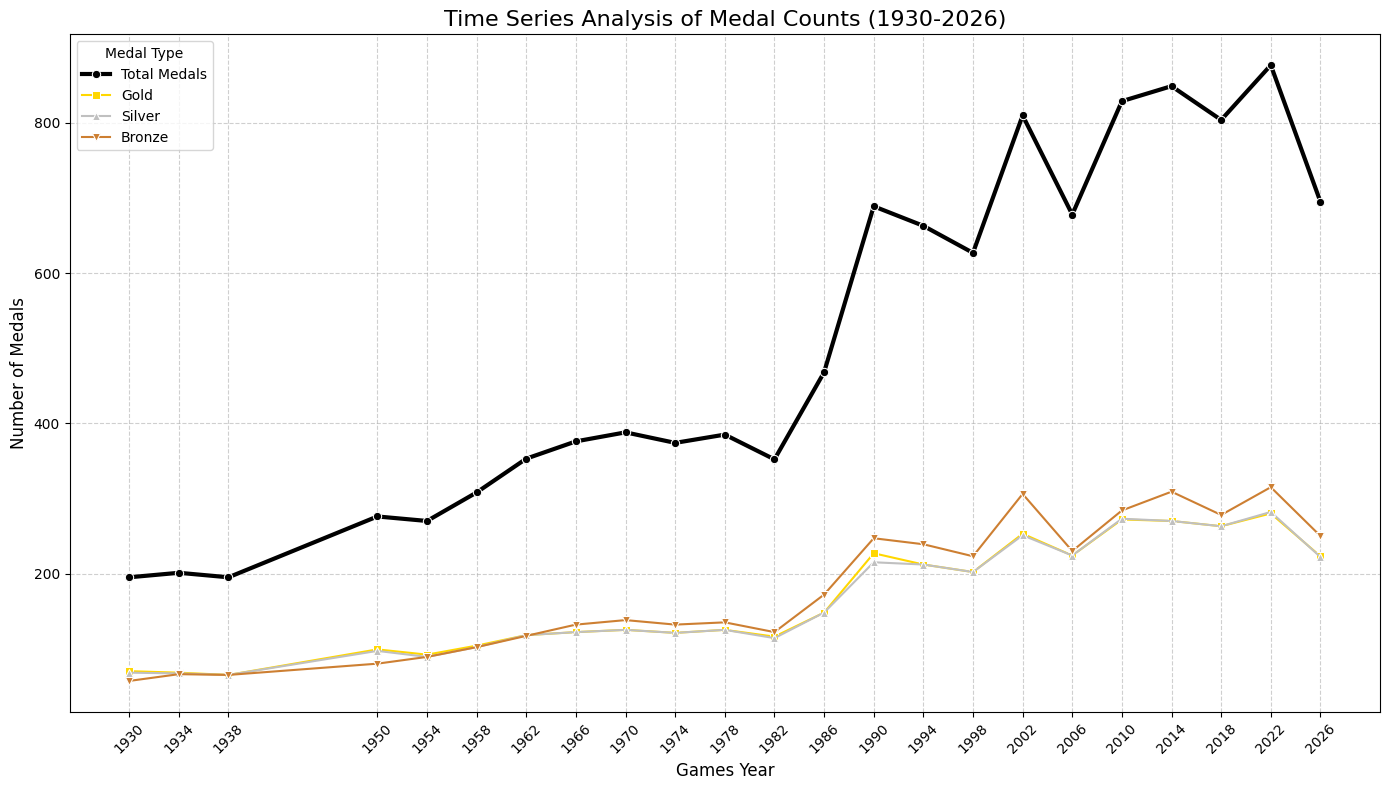

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import kagglehub

# Ensure data is loaded if the kernel was restarted
try:
    df.head()
except NameError:
    dataset_handle = "rupsarroy/96-years-of-commonwealth-games-history-19302026"
    file_name = "Commonwealth_Medalists_1930_2026.csv"
    download_path = kagglehub.dataset_download(dataset_handle)
    csv_file_path = f"{download_path}/{file_name}"
    df = pd.read_csv(csv_file_path)

# 1. Prepare the data: Group by Year and Medal type
medal_trends = df.groupby(['Year', 'Medal']).size().unstack(fill_value=0).reset_index()

# Calculate Total medals per year
# Checking if all columns exist to avoid KeyError
for col in ['Gold', 'Silver', 'Bronze']:
    if col not in medal_trends.columns:
        medal_trends[col] = 0

medal_trends['Total'] = medal_trends['Gold'] + medal_trends['Silver'] + medal_trends['Bronze']

# 2. Plotting
plt.figure(figsize=(14, 8))

# Plot Total medals
sns.lineplot(data=medal_trends, x='Year', y='Total', label='Total Medals', color='black', linewidth=3, marker='o')

# Plot individual medal types
sns.lineplot(data=medal_trends, x='Year', y='Gold', label='Gold', color='#FFD700', marker='s')
sns.lineplot(data=medal_trends, x='Year', y='Silver', label='Silver', color='#C0C0C0', marker='^')
sns.lineplot(data=medal_trends, x='Year', y='Bronze', label='Bronze', color='#CD7F32', marker='v')

# Customizing the plot
plt.title('Time Series Analysis of Medal Counts (1930-2026)', fontsize=16)
plt.xlabel('Games Year', fontsize=12)
plt.ylabel('Number of Medals', fontsize=12)
plt.xticks(medal_trends['Year'].unique(), rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Medal Type')

plt.tight_layout()
plt.show()

### Individual Country Performance Trajectories Over Time

This visualization tracks the total medal counts for the top 5 countries across every edition of the Games, highlighting periods of dominance and shifts in competitiveness.

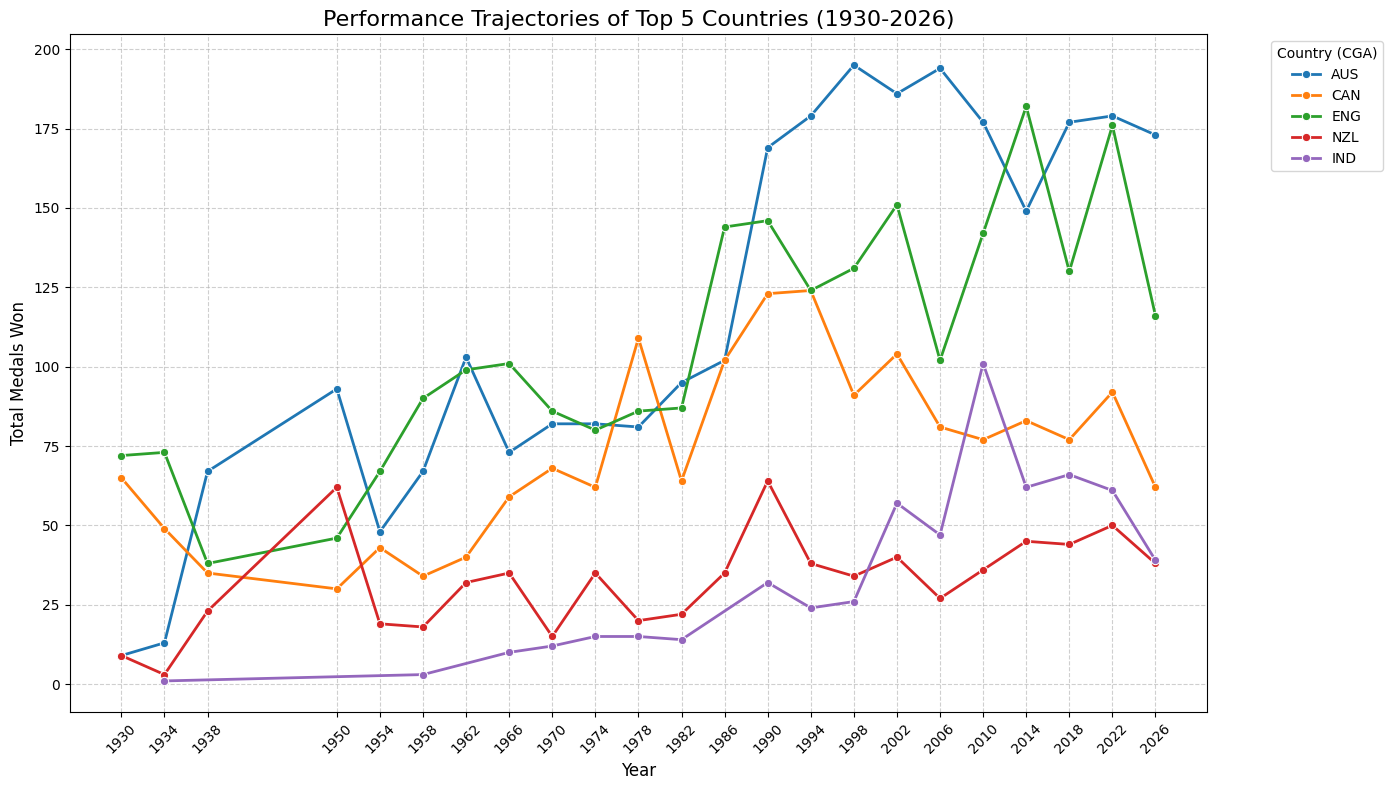

In [ ]:
# 1. Identify the top 5 countries overall
top_5_cgas = df['CGA'].value_counts().head(5).index.tolist()

# 2. Prepare time series data for these countries
country_trends = df[df['CGA'].isin(top_5_cgas)].groupby(['Year', 'CGA']).size().reset_index(name='Medal_Count')

# 3. Plotting
plt.figure(figsize=(14, 8))
sns.lineplot(data=country_trends, x='Year', y='Medal_Count', hue='CGA', marker='o', linewidth=2)

plt.title('Performance Trajectories of Top 5 Countries (1930-2026)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Medals Won', fontsize=12)
plt.xticks(df['Year'].unique(), rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Country (CGA)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Host Nation Advantage Analysis

This analysis compares the performance of countries in the years they hosted the Commonwealth Games against their average performance in years they did not host. This helps determine if there is a statistically significant 'home games' advantage.

<Figure size 1400x800 with 0 Axes>

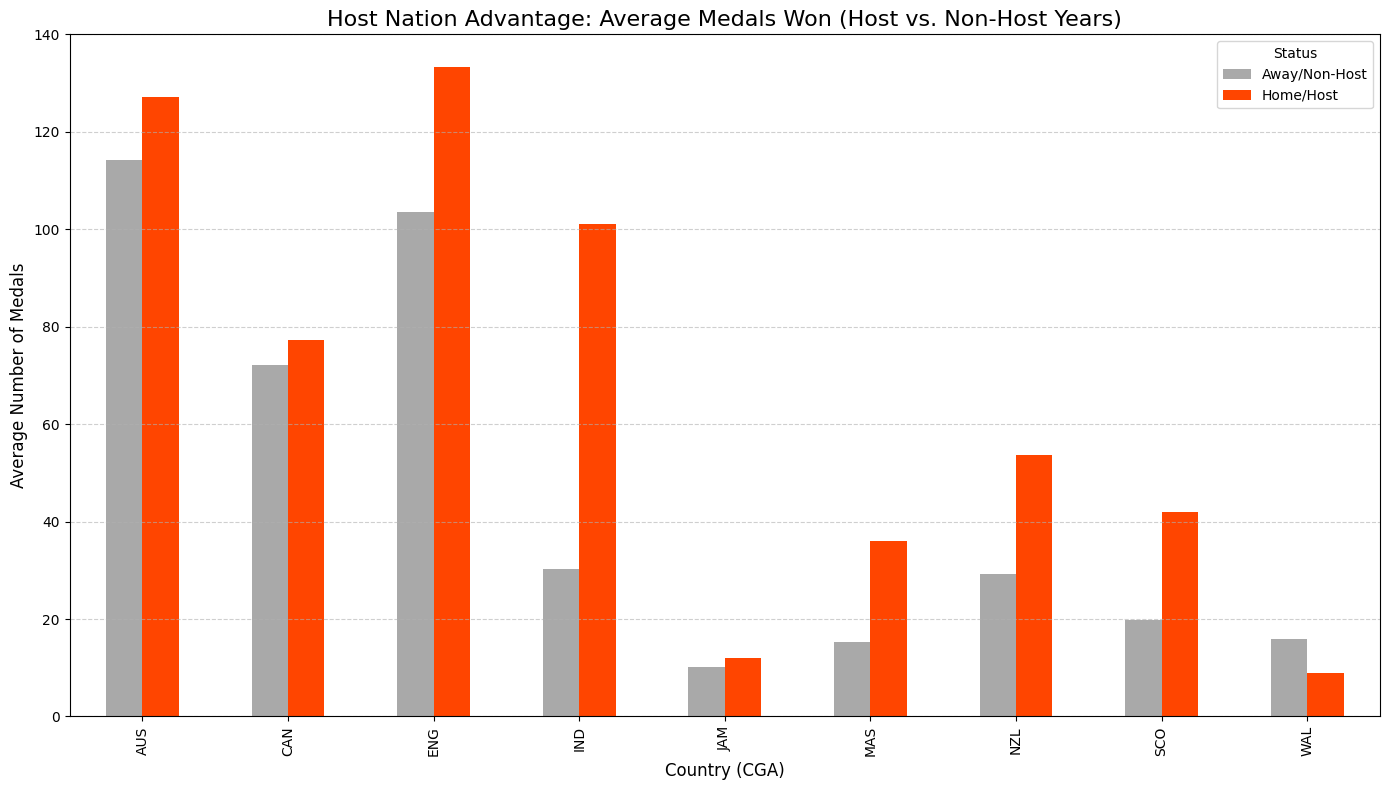

In [ ]:
# 1. Create a mapping of Year to Host Country (CGA)
host_mapping = df[['Year', 'Host_City', 'CGA']].drop_duplicates()
# Note: This requires identifying the actual host CGA. Since the data has 'Host_City',
# we need to map cities to their respective CGAs.

city_to_cga = {
    'Hamilton': 'CAN', 'London': 'ENG', 'Sydney': 'AUS', 'Auckland': 'NZL',
    'Vancouver': 'CAN', 'Cardiff': 'WAL', 'Perth': 'AUS', 'Kingston': 'JAM',
    'Edinburgh': 'SCO', 'Christchurch': 'NZL', 'Brisbane': 'AUS', 'Victoria': 'CAN',
    'Kuala Lumpur': 'MAS', 'Manchester': 'ENG', 'Melbourne': 'AUS', 'Delhi': 'IND',
    'Glasgow': 'SCO', 'Gold Coast': 'AUS', 'Birmingham': 'ENG'
}

df['Host_CGA'] = df['Host_City'].map(city_to_cga)

# 2. Calculate medals per country per year
performance = df.groupby(['Year', 'CGA']).size().reset_index(name='Medals')

# 3. Identify host years
performance['Is_Host'] = performance.apply(lambda x: 1 if x['CGA'] == city_to_cga.get(df[df['Year']==x['Year']]['Host_City'].iloc[0]) else 0, axis=1)

# 4. Compare performance for countries that have hosted at least once
hosting_countries = [cga for cga in city_to_cga.values() if cga in performance['CGA'].unique()]
host_vs_away = performance[performance['CGA'].isin(hosting_countries)].groupby(['CGA', 'Is_Host'])['Medals'].mean().unstack()

# 5. Plotting
plt.figure(figsize=(14, 8))
host_vs_away.plot(kind='bar', figsize=(14, 8), color=['#A9A9A9', '#FF4500'])
plt.title('Host Nation Advantage: Average Medals Won (Host vs. Non-Host Years)', fontsize=16)
plt.xlabel('Country (CGA)', fontsize=12)
plt.ylabel('Average Number of Medals', fontsize=12)
plt.legend(['Away/Non-Host', 'Home/Host'], title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Medal Distribution by Event Gender Over Time

This analysis visualizes the proportion of medals awarded in Men's, Women's, and Mixed events over the decades, highlighting the progress towards gender equality in the Games.

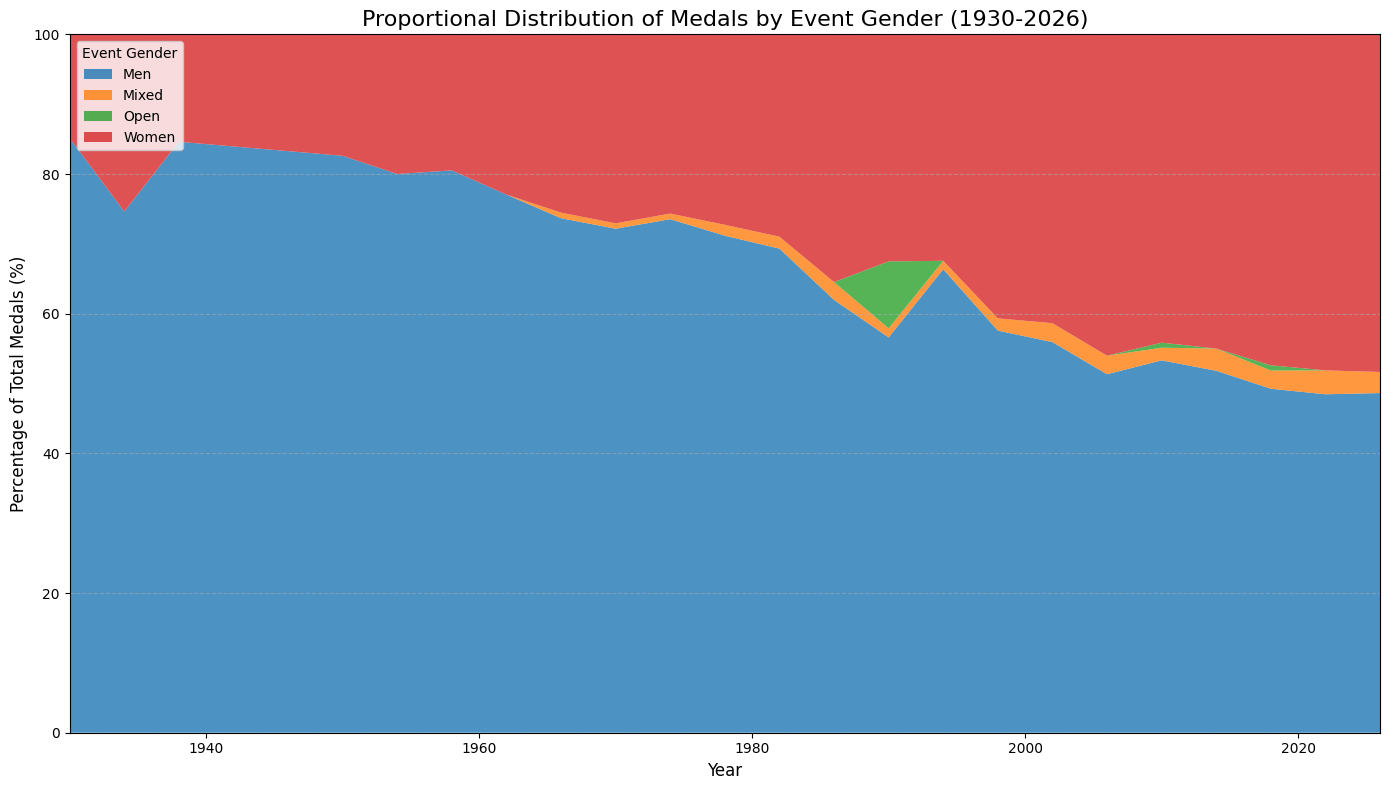

In [ ]:
# 1. Prepare data for gender trends
gender_trends = df.groupby(['Year', 'Event_gender']).size().unstack(fill_value=0).reset_index()

# 2. Calculate percentages for a stacked area chart
gender_trends_pct = gender_trends.copy()
cols = [c for c in gender_trends.columns if c != 'Year']
gender_trends_pct[cols] = gender_trends_pct[cols].div(gender_trends_pct[cols].sum(axis=1), axis=0) * 100

# 3. Plotting
plt.figure(figsize=(14, 8))
plt.stackplot(gender_trends_pct['Year'],
              [gender_trends_pct[c] for c in cols],
              labels=cols,
              alpha=0.8)

plt.title('Proportional Distribution of Medals by Event Gender (1930-2026)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage of Total Medals (%)', fontsize=12)
plt.legend(loc='upper left', title='Event Gender')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.margins(0, 0)

plt.tight_layout()
plt.show()

### Deep Dive: Event-Level Success in Top Sports

This analysis identifies the top 5 specific events within the most medal-heavy sports (Athletics and Swimming) and shows which countries dominate these particular disciplines.

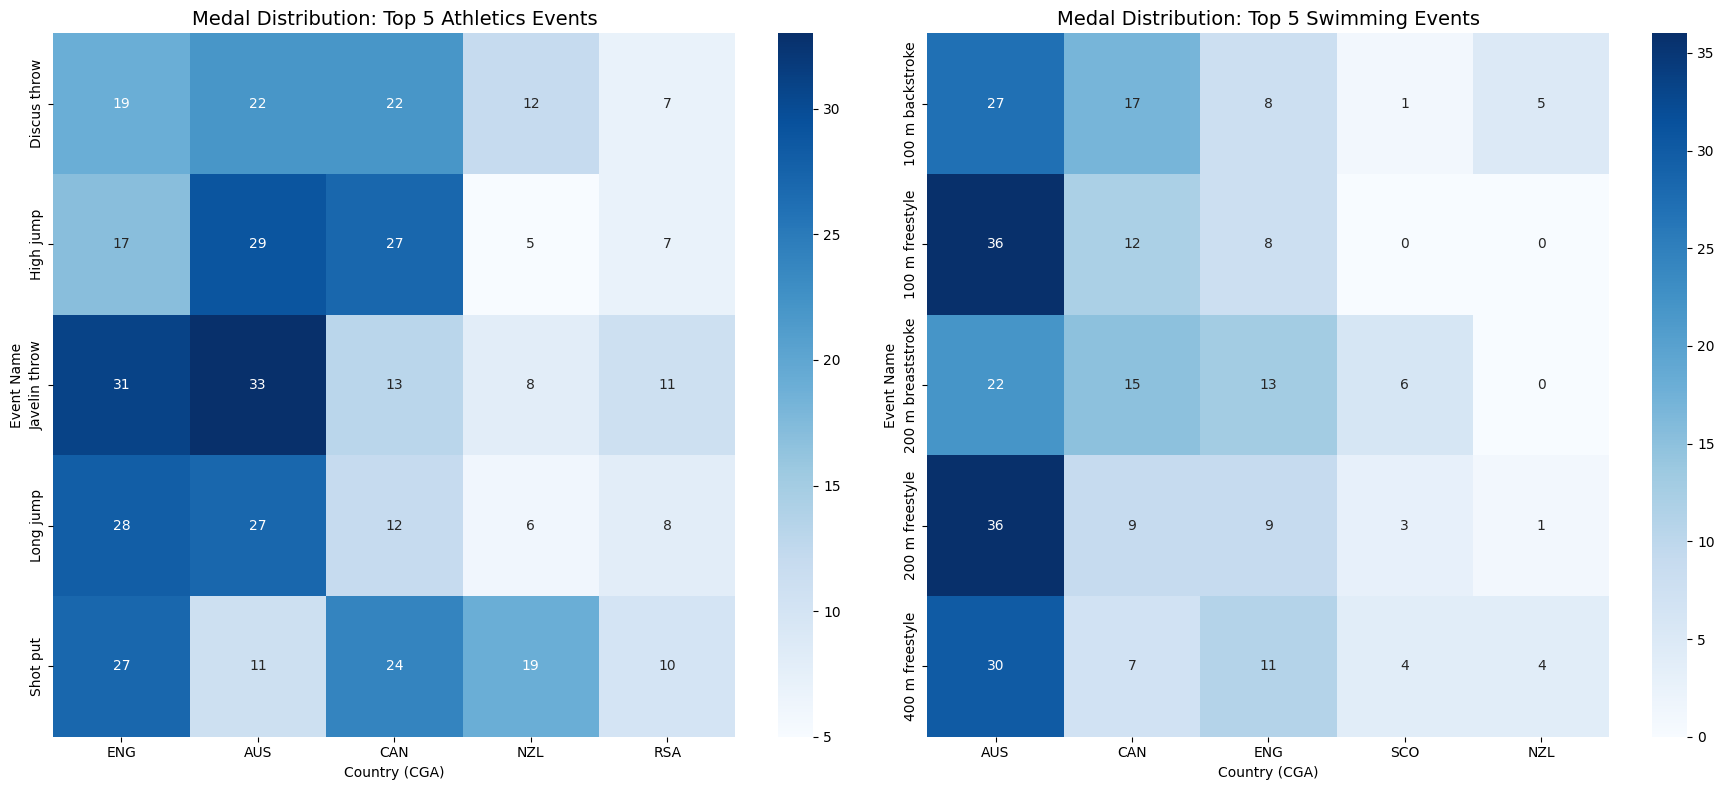

In [ ]:
# 1. Filter for the two most dominant sports
top_sports = ['Athletics', 'Swimming']
df_top_sports = df[df['Sport'].isin(top_sports)]

# 2. Get top 5 events for each sport based on medal volume
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for i, sport in enumerate(top_sports):
    sport_data = df_top_sports[df_top_sports['Sport'] == sport]
    top_events = sport_data['Event'].value_counts().head(5).index
    event_data = sport_data[sport_data['Event'].isin(top_events)]

    # Group by Event and CGA
    event_cga_dist = event_data.groupby(['Event', 'CGA']).size().unstack(fill_value=0)
    # Select only top 5 CGAs for readability in the heatmap
    top_cgas = event_data['CGA'].value_counts().head(5).index
    event_cga_dist = event_cga_dist[top_cgas]

    sns.heatmap(event_cga_dist, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Medal Distribution: Top 5 {sport} Events', fontsize=14)
    axes[i].set_xlabel('Country (CGA)')
    axes[i].set_ylabel('Event Name')

plt.tight_layout()
plt.show()

In [ ]:
# things that would could implement

n= '''
Time Series Analysis of Overall Medal Counts: Although you have medals_by_year,
a clear line plot showing the trend of total medals awarded per Games year would
 visually emphasize the growth or changes in the scale of the Commonwealth Games
  over time. You could extend this to separate lines for Gold, Silver, and Bronze medals.

Individual Country Performance Over Time: For the top 5 or 10 medal-winning
countries, creating line plots that show their total medal count (or Gold medal count)
 across different Games years would reveal their individual trajectories,
 periods of dominance, and how consistent their performance has been.

Deep Dive into Top Sports by Event: For the sports that yield the most medals
(e.g., Athletics, Swimming, Weightlifting as identified in your charts),
a breakdown of medal counts by specific events within those sports would be
interesting. This could highlight which particular disciplines contribute most
to a country's success in a given sport.

Host Nation Advantage Analysis: Investigate whether hosting the Games provides
 a significant boost to a country's medal count in that specific year. You could
  compare the host nation's medal performance during host years versus their
  average performance in other years.

Medal Distribution by Event Gender: Since you have an 'Event_gender' column,
 analyzing and visualizing the distribution of medals across 'Men', 'Women', and
  'Mixed' events within various sports could highlight any patterns or shifts in
   gender participation and success over time.

 '''

## Predictive Modeling: What will happen?

In this section, we use a Linear Regression model to forecast the growth of the Commonwealth Games. By training on the total medal counts from 1930 to 2022, we can project the scale of the 2026 Games and beyond.

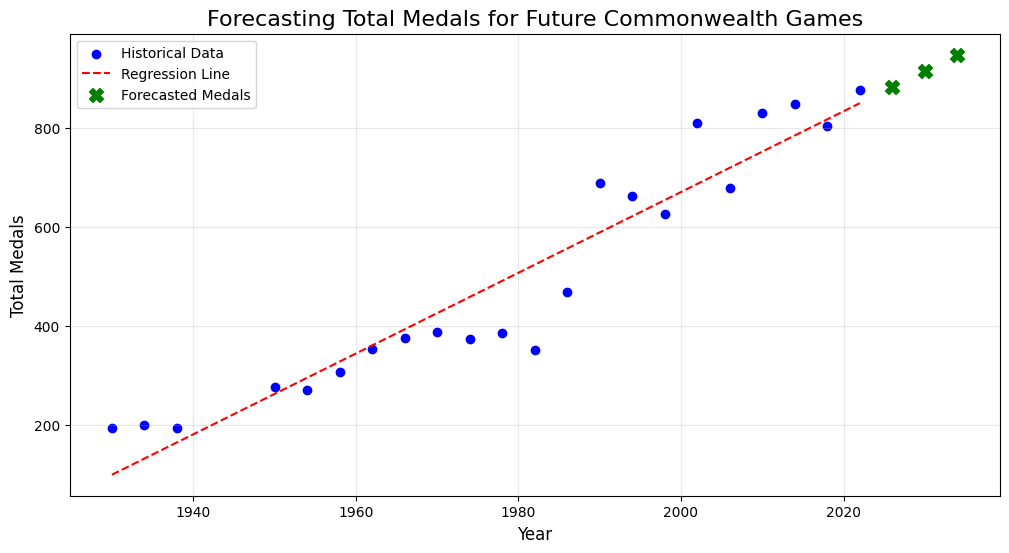

Predicted total medals for 2026: 882
Predicted total medals for 2030: 915
Predicted total medals for 2034: 947


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Prepare data (using realized data up to 2022)
# Filter out 2026 if it's currently stored as a projection in the dataset
train_df = medal_trends[medal_trends['Year'] <= 2022]

X = train_df['Year'].values.reshape(-1, 1)
y = train_df['Total'].values

# 2. Build and fit the model
model = LinearRegression()
model.fit(X, y)

# 3. Predict for future years (2026, 2030, 2034)
future_years = np.array([2026, 2030, 2034]).reshape(-1, 1)
predictions = model.predict(future_years)

# 4. Visualization of the trend and forecast
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Historical Data')
plt.plot(X, model.predict(X), color='red', linestyle='--', label='Regression Line')

# Plot predictions
plt.scatter(future_years, predictions, color='green', marker='X', s=100, label='Forecasted Medals')

plt.title('Forecasting Total Medals for Future Commonwealth Games', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Medals', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for year, pred in zip(future_years.flatten(), predictions):
    print(f"Predicted total medals for {year}: {int(pred)}")

### Advanced Forecasting with Prophet

Prophet is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality. Here, we use it to capture the long-term growth trend of the Games while acknowledging the 4-year cycle.

INFO:prophet:n_changepoints greater than number of observations. Using 16.


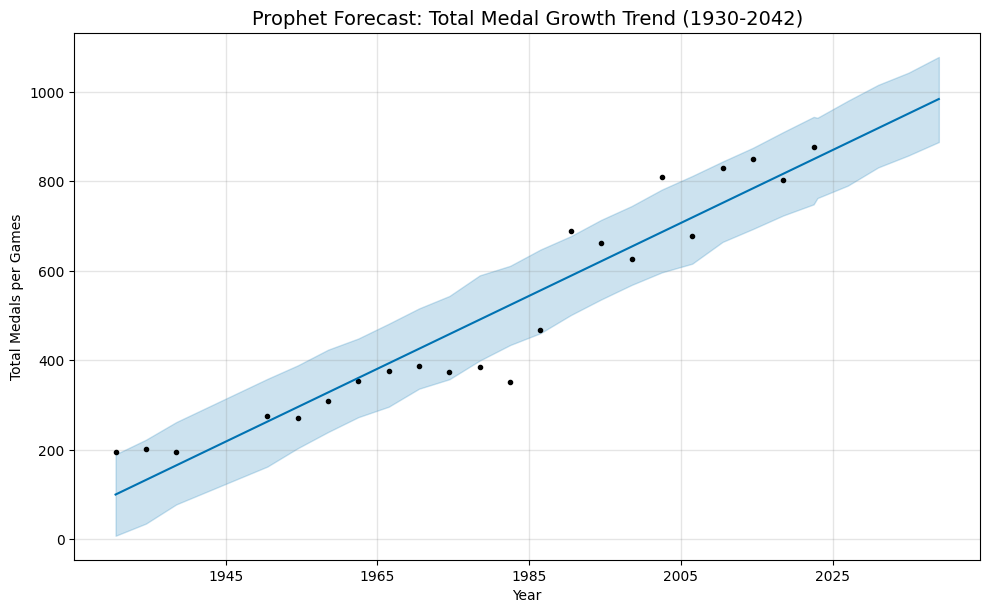

,Year,yhat,yhat_lower,yhat_upper
22,2022,853.567157,762.541233,941.984523
23,2026,886.155651,790.290771,979.816560
24,2030,918.744144,830.997807,1015.535945
25,2034,951.332637,857.737239,1042.709572
26,2038,983.921130,887.774610,1077.939303


In [ ]:
from prophet import Prophet
import pandas as pd

# 1. Aggregate data by Year to get total medals per Games edition
# This provides a cleaner signal for the model than daily grouping
prophet_df = df[df['Year'] <= 2022].groupby('Year').size().reset_index()
prophet_df.columns = ['ds', 'y']

# Convert 'ds' to a datetime format Prophet expects (using July 1st of that year)
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'].astype(str) + '-07-01')

# 2. Initialize and Fit the Model
# We allow for a growth trend and fit the historical expansion
m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, growth='linear')
m.fit(prophet_df)

# 3. Create future dates (4-year intervals for the next 20 years)
future = m.make_future_dataframe(periods=5, freq='4YE')
forecast = m.predict(future)

# 4. Visualization
fig1 = m.plot(forecast)
plt.title('Prophet Forecast: Total Medal Growth Trend (1930-2042)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Medals per Games')
plt.show()

# 5. Display the numerical forecast summary
forecast_summary = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5)
forecast_summary['Year'] = forecast_summary['ds'].dt.year
display(forecast_summary[['Year', 'yhat', 'yhat_lower', 'yhat_upper']])

### Country-Level Forecasting with Random Forest

In this section, we shift from predicting the total scale of the Games to predicting individual country success. We will use historical performance and host status as features to train a Random Forest Regressor.

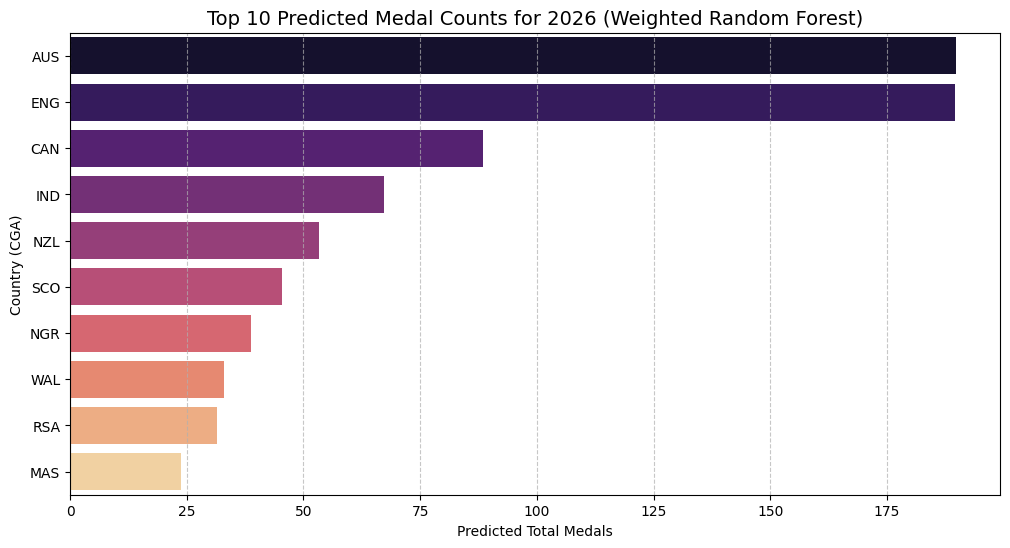

,CGA,Athlete_Count,Prev_Medals,Predicted_Medals
525,AUS,151,179,189.720000
534,ENG,161,176,189.480000
530,CAN,81,92,88.360000
540,IND,61,61,67.210000
554,NZL,45,50,53.310000
559,SCO,39,51,45.430000
550,NGR,34,34,38.840000
566,WAL,27,28,33.030000
557,RSA,23,27,31.399002
545,MAS,22,23,23.668333


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Enhanced Feature Engineering
country_stats = df.groupby(['Year', 'CGA']).agg(
    Medals=('Medal', 'size'),
    Athlete_Count=('Athlete', 'nunique')
).reset_index()

host_cga_per_year = {1930: 'CAN', 1934: 'ENG', 1938: 'AUS', 1950: 'NZL', 1954: 'CAN',
                     1958: 'WAL', 1962: 'AUS', 1966: 'JAM', 1970: 'SCO', 1974: 'NZL',
                     1978: 'CAN', 1982: 'AUS', 1986: 'SCO', 1990: 'NZL', 1994: 'CAN',
                     1998: 'MAS', 2002: 'ENG', 2006: 'AUS', 2010: 'IND', 2014: 'SCO',
                     2018: 'AUS', 2022: 'ENG', 2026: 'SCO'}

country_stats['Is_Host'] = country_stats.apply(lambda x: 1 if x['CGA'] == host_cga_per_year.get(x['Year']) else 0, axis=1)
country_stats = country_stats.sort_values(['CGA', 'Year'])
country_stats['Prev_Medals'] = country_stats.groupby('CGA')['Medals'].shift(1)

# Handle missing data and create a formal copy
model_data = country_stats.dropna(subset=['Prev_Medals']).copy()

# 2. Time-Weighted Decay Calculation
max_year = model_data['Year'].max()
model_data['Weight'] = np.exp((model_data['Year'] - max_year) / 20)

# 3. Train/Test Split
train = model_data[model_data['Year'] < 2022]
features = ['Prev_Medals', 'Is_Host', 'Athlete_Count']

X_train, y_train, weights_train = train[features], train['Medals'], train['Weight']

# 4. Model Training
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train, sample_weight=weights_train)

# 5. Predict 2026
predict_2026 = country_stats[country_stats['Year'] == 2022].copy()
predict_2026['Year'] = 2026
predict_2026['Prev_Medals'] = predict_2026['Medals']
predict_2026['Is_Host'] = predict_2026.apply(lambda x: 1 if x['CGA'] == 'SCO' else 0, axis=1)

predict_2026['Predicted_Medals'] = rf_model.predict(predict_2026[features])

# 6. Visualization (Updated to fix FutureWarning)
top_10_pred = predict_2026.sort_values(by='Predicted_Medals', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_pred, x='Predicted_Medals', y='CGA', hue='CGA', palette='magma', legend=False)
plt.title('Top 10 Predicted Medal Counts for 2026 (Weighted Random Forest)', fontsize=14)
plt.xlabel('Predicted Total Medals')
plt.ylabel('Country (CGA)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(top_10_pred[['CGA', 'Athlete_Count', 'Prev_Medals', 'Predicted_Medals']])

--- Ways to Improve the Prediction ---
1. Incorporate GDP & Population: Economic resources and talent pool are strong predictors of medal success.
3. Sport-Specific Strength: Calculating a country's historical strength in specific sports (e.g., India in Wrestling).

5. Hyperparameter Tuning: Using GridSearchCV to optimize the Random Forest (max_depth, n_estimators).
6. Feature Crosses: Interactions between Host Status and Total Events available in that specific year.

---
4. Time-Weighted Decay: Giving more weight to recent performance (2022) than performance from the 1950s.
2. Athlete Count: Using the number of athletes a country sends per sport as a feature.

https://www.kaggle.com/datasets/rupsarroy/96-years-of-commonwealth-games-history-19302026